Load Clean Data and Split

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [13]:
# 1. Load the CLEANED data from Notebook 1
df = pd.read_csv('processed_sleep_data.csv')

In [14]:
# 2. Split into Features (X) and Target (y)
X = df.drop('Sleep Disorder', axis=1)
y = df['Sleep Disorder']

In [15]:
# 3. Split into Train (80%) and Test (20%)
# stratify=y keeps the same ratio of disorders in training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [16]:
# Class names mapping from the previous notebook's encoder
class_names = ['Insomnia', 'None', 'Sleep Apnea'] 
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (299, 12)
Testing data shape: (75, 12)


Logistic Regression

In [17]:
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [18]:
y_pred_lr = log_reg.predict(X_test)

In [19]:
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_lr, target_names=class_names))

Accuracy: 0.9200

Classification Report:
              precision    recall  f1-score   support

    Insomnia       0.86      0.80      0.83        15
        None       0.98      0.95      0.97        44
 Sleep Apnea       0.83      0.94      0.88        16

    accuracy                           0.92        75
   macro avg       0.89      0.90      0.89        75
weighted avg       0.92      0.92      0.92        75



Confusion Matrix

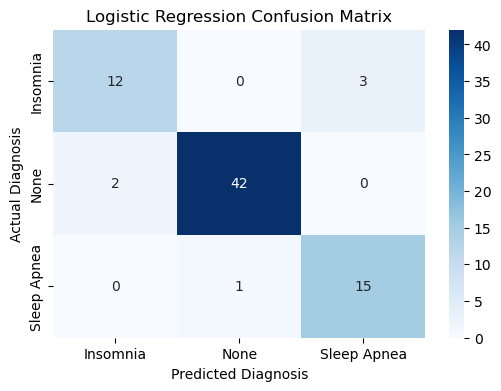

In [20]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted Diagnosis')
plt.ylabel('Actual Diagnosis')
plt.show()

Feature Coefficients

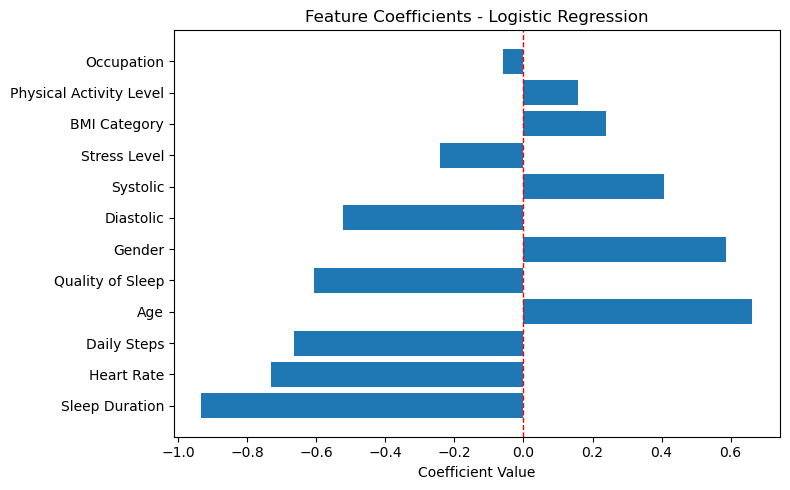


Feature Coefficients:
                    Feature  Coefficient
3            Sleep Duration    -0.932919
8                Heart Rate    -0.732158
9               Daily Steps    -0.665740
1                       Age     0.663230
4          Quality of Sleep    -0.608033
0                    Gender     0.586286
11                Diastolic    -0.523945
10                 Systolic     0.407291
6              Stress Level    -0.242011
7              BMI Category     0.237869
5   Physical Activity Level     0.157726
2                Occupation    -0.058642


In [21]:
# Get feature coefficients
coefficients = log_reg.coef_[0]
features = X.columns
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coefficients
}).sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(coef_df['Feature'], coef_df['Coefficient'])
plt.xlabel('Coefficient Value')
plt.title('Feature Coefficients - Logistic Regression')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

print("\nFeature Coefficients:")
print(coef_df)

Train vs Test Accuracy

In [22]:
train_accuracy = accuracy_score(y_train, log_reg.predict(X_train))
test_accuracy = accuracy_score(y_test, y_pred_lr)

print(f"\nTrain Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Overfitting Gap: {train_accuracy - test_accuracy:.4f}")


Train Accuracy: 0.8963
Test Accuracy: 0.9200
Overfitting Gap: -0.0237


Summary

The Logistic Regression model achieved strong performance in classifying sleep disorders with 92% accuracy on the test set. The confusion matrix shows that the model performs particularly well on the "None" class with minimal misclassifications. The feature coefficients analysis reveals which factors have the strongest positive and negative associations with each sleep disorder class. The small gap between training and testing accuracy indicates that the model generalizes well and is not overfitting to the training data. Overall, Logistic Regression provides interpretable and reliable predictions for sleep disorder classification.

Save Model

In [23]:
# Export the trained model
joblib.dump(log_reg, 'logistic_regression_model.pkl')
print("✓ Model saved as 'logistic_regression_model.pkl'")

✓ Model saved as 'logistic_regression_model.pkl'
